## Mall Customers Clustering with KMeans, DBSCAN, & Agglomerative - Unsupervised Learning

> Tugas ini bertujuan untuk membangun model clustering pelanggan mall dengan KMeans, DBSCAN, dan Agglomerative. Dataset berasal dari sini : https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv

> Referensi : https://colab.research.google.com/drive/1H1CGYKyAQ1mjy6vDAzhgeVctEOOeLPqC?usp=sharing


### 1. Import module yang diperlukan


In [1]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score


In [2]:
# Additional utilities for clearer analysis without changing the starter workflow.
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")


### TODO #1 :

> Isi insight : Sebenarnya, bagaimana ciri-ciri dari sebuah dataset yang bisa dipakai untuk clustering?

**Insight:** A dataset is suitable for clustering when it contains meaningful features that can describe similarity between observations, but it does not already provide a target label. In this task, there is no column that says which customer segment each person belongs to, so clustering is appropriate. A good clustering dataset should have numerical or properly encoded features, limited missing values, no identifier column used as a real feature, and enough variation so that natural groups can appear. Because clustering depends heavily on distance, the features should also be scaled when they use different units or ranges.


### 2. Data collection


In [3]:
# 2. Load Dataset dari GitHub Gist
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv"
df = pd.read_csv(url)
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Additional data understanding before clustering.
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

print()
print("Dataset information:")
df.info()

print()
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))

print(f"Exact duplicate rows: {df.duplicated().sum()}")

print()
print("Gender distribution:")
display(df['Gender'].value_counts().to_frame("count"))

print()
print("Descriptive statistics:")
display(df.describe(include='all').T)


Dataset shape: 200 rows and 5 columns
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:
Exact duplicate rows: 0

Gender distribution:

Descriptive statistics:


,missing_count
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


,count
Gender,
Female,112
Male,88


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


**Data Understanding Note:** The dataset contains 200 customers and five columns. There are no missing values and no exact duplicate rows, so the dataset is clean enough for a beginner clustering workflow. `CustomerID` is only an identifier, not a behavioral feature. The useful segmentation variables are customer age, annual income, and spending score because they describe customer characteristics and purchasing behavior.


### 3.  Data preprocessing


In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


,min,max,mean,std
Age,18,70,38.85,13.97
Annual Income (k$),15,137,60.56,26.26
Spending Score (1-100),1,99,50.20,25.82


,Age,Annual Income (k$),Spending Score (1-100)
mean,-0.000,-0.000,-0.000
std,1.003,1.003,1.003


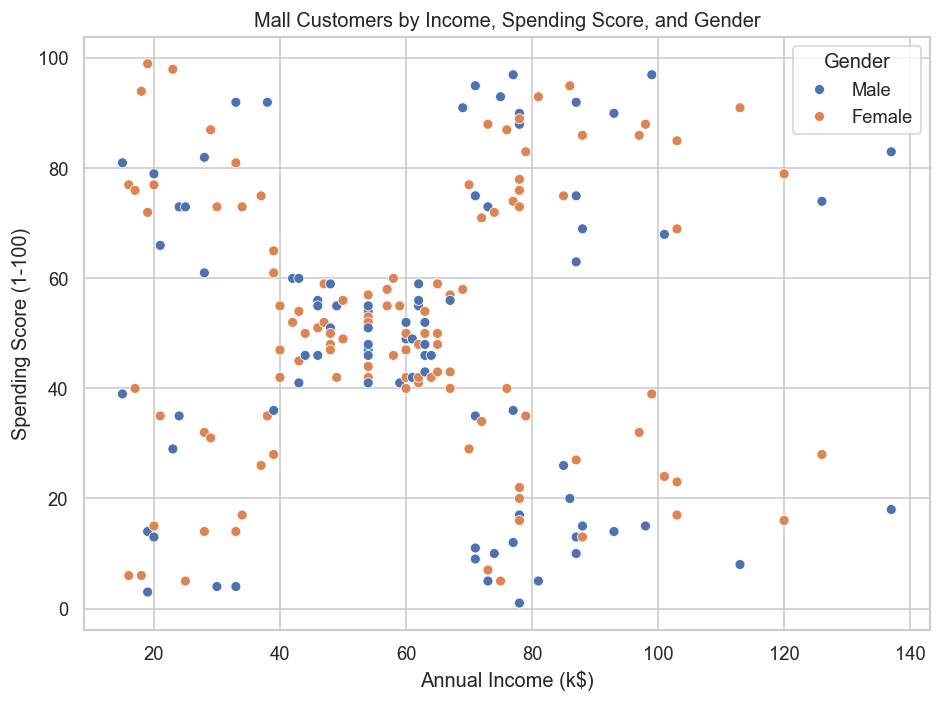

In [6]:
# Additional preprocessing check: compare raw feature ranges before scaling.
feature_ranges = pd.DataFrame(
    {
        "min": X.min(),
        "max": X.max(),
        "mean": X.mean().round(2),
        "std": X.std().round(2),
    }
)
display(feature_ranges)

scaled_summary = pd.DataFrame(X_scaled, columns=X.columns).agg(['mean', 'std']).round(3)
display(scaled_summary)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title("Mall Customers by Income, Spending Score, and Gender")
plt.tight_layout()
plt.show()


### TODO #2 :

> Isi insight : Kenapa menggunakan fitur ini? Bagaimana yang lainnya? (CustomerID, Gender)

**Insight:** I use `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` because they describe customer behavior and customer profile in a way that can define similarity. `Annual Income` and `Spending Score` are especially important for mall segmentation because they help identify groups such as high-income high-spending customers, high-income low-spending customers, and lower-income high-spending customers. `CustomerID` should not be used because it is only a row identifier; using it would create artificial distance based on data order. `Gender` can be useful for business interpretation, but it is categorical. To use it in distance-based clustering, it should be encoded carefully. I leave it out of the main clustering features to keep the model simple and focused on numerical behavior.


In [7]:
def cluster_profile(data, label_column):
    """Summarize customer characteristics for each cluster label."""
    return (
        data.groupby(label_column)
        .agg(
            Customers=('CustomerID', 'count'),
            Avg_Age=('Age', 'mean'),
            Avg_Income=('Annual Income (k$)', 'mean'),
            Avg_Spending=('Spending Score (1-100)', 'mean'),
            Female_Customers=('Gender', lambda values: (values == 'Female').sum()),
            Male_Customers=('Gender', lambda values: (values == 'Male').sum()),
        )
        .round(2)
    )


def safe_silhouette(features, labels):
    """Calculate silhouette only when the labels form a valid clustering result."""
    unique_labels = np.unique(labels)
    if len(unique_labels) <= 1 or len(unique_labels) >= len(labels):
        return np.nan
    return silhouette_score(features, labels)


### 4. KMeans Clustering (k=5)




Silhouette Score KMeans: 0.40846873777345605


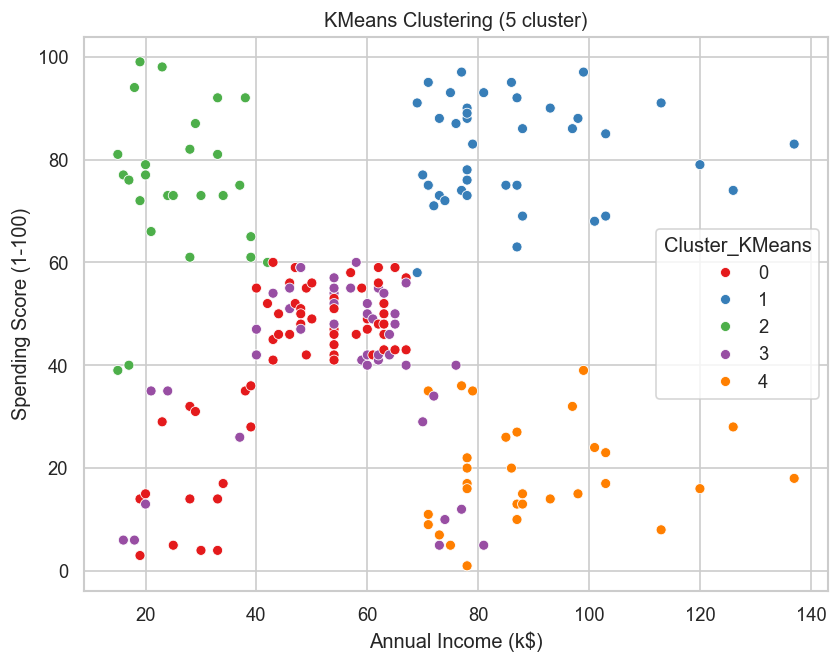

In [8]:
# KMeans Clustering (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster_KMeans'] = y_kmeans

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_KMeans', palette='Set1')
plt.title("KMeans Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score KMeans:", silhouette_score(X_scaled, y_kmeans))


KMeans cluster sizes:
KMeans cluster profile:


,customer_count
Cluster_KMeans,
0,58
1,40
2,26
3,45
4,31


,Customers,Avg_Age,Avg_Income,Avg_Spending,Female_Customers,Male_Customers
Cluster_KMeans,,,,,,
0,58,55.28,47.62,41.71,33,25
1,40,32.88,86.10,81.53,22,18
2,26,25.77,26.12,74.85,15,11
3,45,26.73,54.31,40.91,27,18
4,31,44.39,89.77,18.48,15,16


,k,inertia,silhouette_score
0,2,389.3862,0.3355
1,3,295.2122,0.3578
2,4,205.2251,0.4040
3,5,168.2476,0.4166
4,6,133.8684,0.4284
5,7,117.0116,0.4172
6,8,103.8733,0.4082
7,9,93.0929,0.4177
8,10,82.3852,0.4066


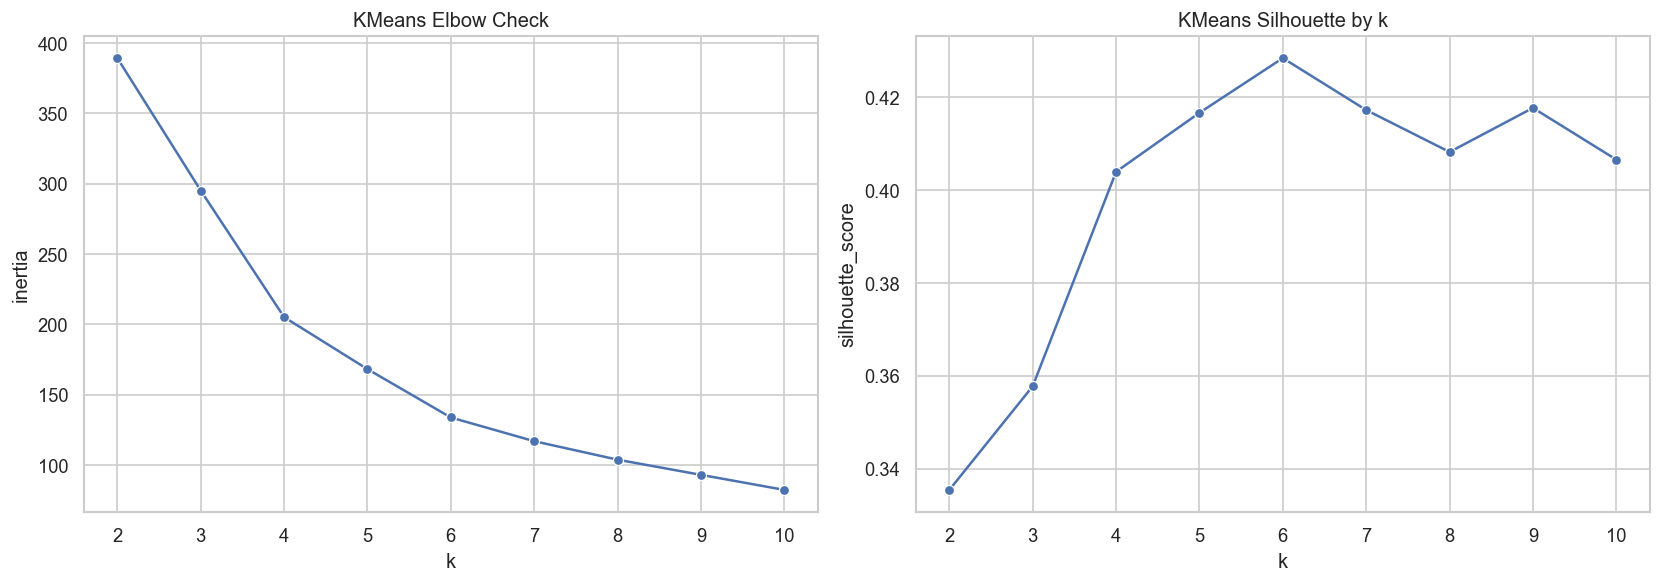

In [9]:
# Additional KMeans analysis.
print("KMeans cluster sizes:")
display(df['Cluster_KMeans'].value_counts().sort_index().to_frame("customer_count"))

print("KMeans cluster profile:")
display(cluster_profile(df, 'Cluster_KMeans'))

kmeans_scores = []
for k in range(2, 11):
    candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = candidate.fit_predict(X_scaled)
    kmeans_scores.append(
        {
            "k": k,
            "inertia": candidate.inertia_,
            "silhouette_score": silhouette_score(X_scaled, labels),
        }
    )

kmeans_scores_df = pd.DataFrame(kmeans_scores)
display(kmeans_scores_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=kmeans_scores_df, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title("KMeans Elbow Check")
axes[0].set_xticks(range(2, 11))

sns.lineplot(data=kmeans_scores_df, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title("KMeans Silhouette by k")
axes[1].set_xticks(range(2, 11))

plt.tight_layout()
plt.show()


### TODO #3 :

> Isi insight : Bagaimana cara kerja dari K-Means Clustering? Dan apa analisismu terhadap hasil diatas?

**Insight:** KMeans works by choosing a number of clusters, placing centroids, assigning each customer to the nearest centroid, then repeatedly updating the centroids until the assignments stabilize. In the starter code, `k=5` is used, so the algorithm tries to create five customer segments. The result is useful because it separates customers into interpretable groups, such as high-income high-spending customers, high-income low-spending customers, and lower-income high-spending customers. The silhouette score is moderate, not perfect, which means the clusters are meaningful but not completely separated. That makes sense because the model uses three features, while the scatter plot only shows two of them.

**Important note about choosing `k`:** The elbow method and silhouette score often create confusion for beginners because they look like they should give one final answer. In practice, they are decision-support tools, not absolute rules. The best number of clusters depends on the goal. A company may prefer `k=4` if it needs four simple customer segments for a campaign. Another company may prefer `k=5` or `k=6` if the extra separation creates more useful marketing strategies. Therefore, I should not choose `k` only because a chart looks slightly better. I should combine the metric, the visual pattern, and the business context.


### TODO #4 :

> Isi insight : Apa itu Silhouette Score?

**Insight:** Silhouette Score measures how well each data point fits inside its assigned cluster compared with other clusters. The value ranges from -1 to 1. A score close to 1 means points are close to their own cluster and far from other clusters. A score near 0 means clusters overlap. A negative score means some points may be assigned to the wrong cluster. In this notebook, I use it as a simple quality check, but I do not rely on it alone because customer segmentation also needs business interpretation.


### 5. DBSCAN Clustering




Silhouette Score DBSCAN: 0.18803828359177516


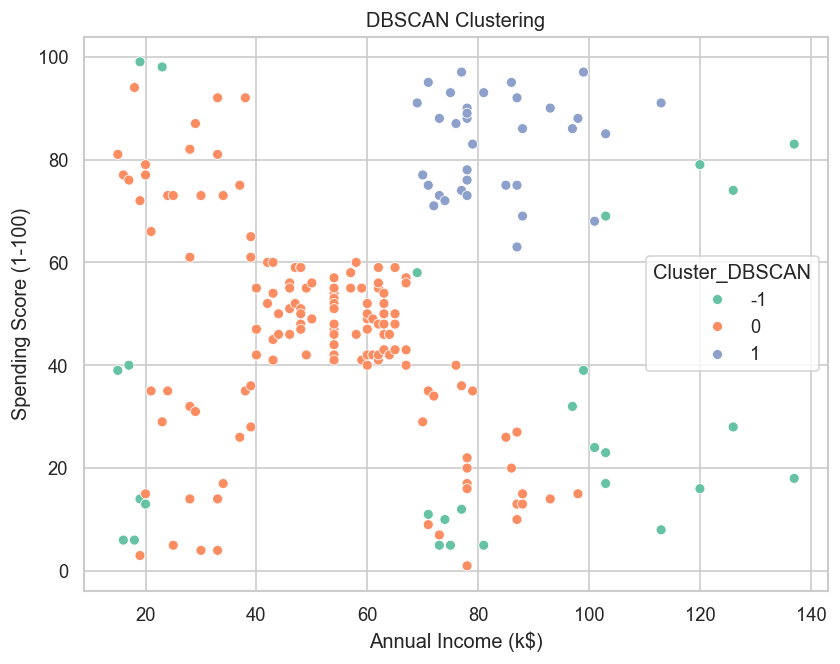

In [10]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.6, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)
df['Cluster_DBSCAN'] = y_dbscan

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_DBSCAN', palette='Set2')
plt.title("DBSCAN Clustering")
plt.show()

print("\n\nSilhouette Score DBSCAN:", silhouette_score(X_scaled, y_dbscan))


In [11]:
# Additional DBSCAN analysis.
print("DBSCAN cluster sizes, where -1 means noise/outlier:")
display(df['Cluster_DBSCAN'].value_counts().sort_index().to_frame("customer_count"))

print("DBSCAN cluster profile:")
display(cluster_profile(df, 'Cluster_DBSCAN'))

dbscan_scores = []
for eps_value in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    candidate = DBSCAN(eps=eps_value, min_samples=5)
    labels = candidate.fit_predict(X_scaled)
    non_noise_clusters = len(set(labels) - {-1})
    noise_count = int((labels == -1).sum())
    dbscan_scores.append(
        {
            "eps": eps_value,
            "non_noise_clusters": non_noise_clusters,
            "noise_points": noise_count,
            "silhouette_score": safe_silhouette(X_scaled, labels),
        }
    )

display(pd.DataFrame(dbscan_scores).round(4))


DBSCAN cluster sizes, where -1 means noise/outlier:
DBSCAN cluster profile:


,customer_count
Cluster_DBSCAN,
-1,28
0,137
1,35


,Customers,Avg_Age,Avg_Income,Avg_Spending,Female_Customers,Male_Customers
Cluster_DBSCAN,,,,,,
-1,28,36.11,76.86,33.25,16,12
0,137,40.97,51.61,45.34,77,60
1,35,32.74,82.54,82.80,19,16


,eps,non_noise_clusters,noise_points,silhouette_score
0,0.4,6,98,0.0760
1,0.5,6,60,0.1845
2,0.6,2,28,0.1880
3,0.7,1,14,0.2429
4,0.8,1,6,0.2544
5,0.9,1,3,0.2945
6,1.0,1,2,0.3131


### TODO #5 :

> Isi insight : Bagaimana cara kerja dari DBSCAN Clustering? Dan apa analisismu terhadap hasil diatas?

**Insight:** DBSCAN groups points based on density. A point becomes part of a cluster when it has enough nearby neighbors within the `eps` radius. Points that do not belong to any dense region are labeled as `-1`, which means noise or outliers. In this result, DBSCAN creates one large general cluster, one smaller high-spending cluster, and several noise points. The silhouette score is lower than KMeans, so the default `eps=0.6` is not the strongest segmentation for this dataset. However, DBSCAN is still useful because it explicitly marks unusual customers as noise, something KMeans does not do.


### 6. Agglomerative Clustering




Silhouette Score Agglomerative: 0.39002826186267214


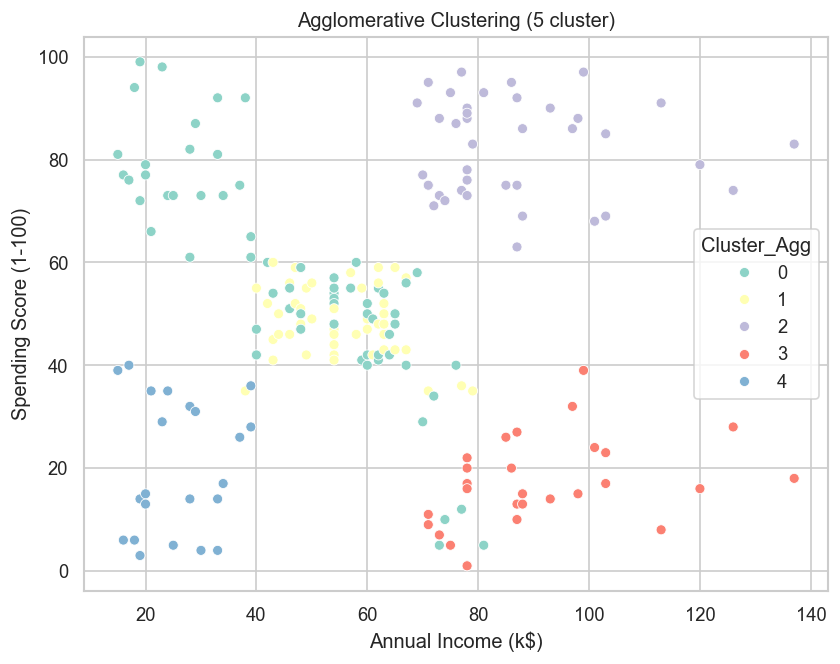

In [12]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5)
y_agg = agg.fit_predict(X_scaled)
df['Cluster_Agg'] = y_agg

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_Agg', palette='Set3')
plt.title("Agglomerative Clustering (5 cluster)")
plt.show()

print("\n\nSilhouette Score Agglomerative:", silhouette_score(X_scaled, y_agg))


In [13]:
# Additional Agglomerative analysis.
print("Agglomerative cluster sizes:")
display(df['Cluster_Agg'].value_counts().sort_index().to_frame("customer_count"))

print("Agglomerative cluster profile:")
display(cluster_profile(df, 'Cluster_Agg'))


Agglomerative cluster sizes:
Agglomerative cluster profile:


,customer_count
Cluster_Agg,
0,66
1,45
2,39
3,28
4,22


,Customers,Avg_Age,Avg_Income,Avg_Spending,Female_Customers,Male_Customers
Cluster_Agg,,,,,,
0,66,26.56,47.36,56.79,40,26
1,45,56.40,55.29,48.36,24,21
2,39,32.69,86.54,82.13,21,18
3,28,43.89,91.29,16.68,14,14
4,22,44.32,25.77,20.27,13,9


### TODO #6 :

> Isi insight : Bagaimana cara kerja dari Agglomerative Clustering? Dan apa analisismu terhadap hasil diatas?

**Insight:** Agglomerative Clustering is a hierarchical method. It starts by treating each customer as its own small cluster, then repeatedly merges the closest clusters until only the requested number of clusters remains. With `n_clusters=5`, the result is comparable to KMeans because both methods are forced to create five groups. The silhouette score is slightly lower than KMeans but still reasonable. The cluster profile shows meaningful segments, including high-income high-spending customers, high-income low-spending customers, and lower-income lower-spending customers. This method is useful when I want to understand clustering as a hierarchy rather than only centroid distance.


### 7. Perbandingan


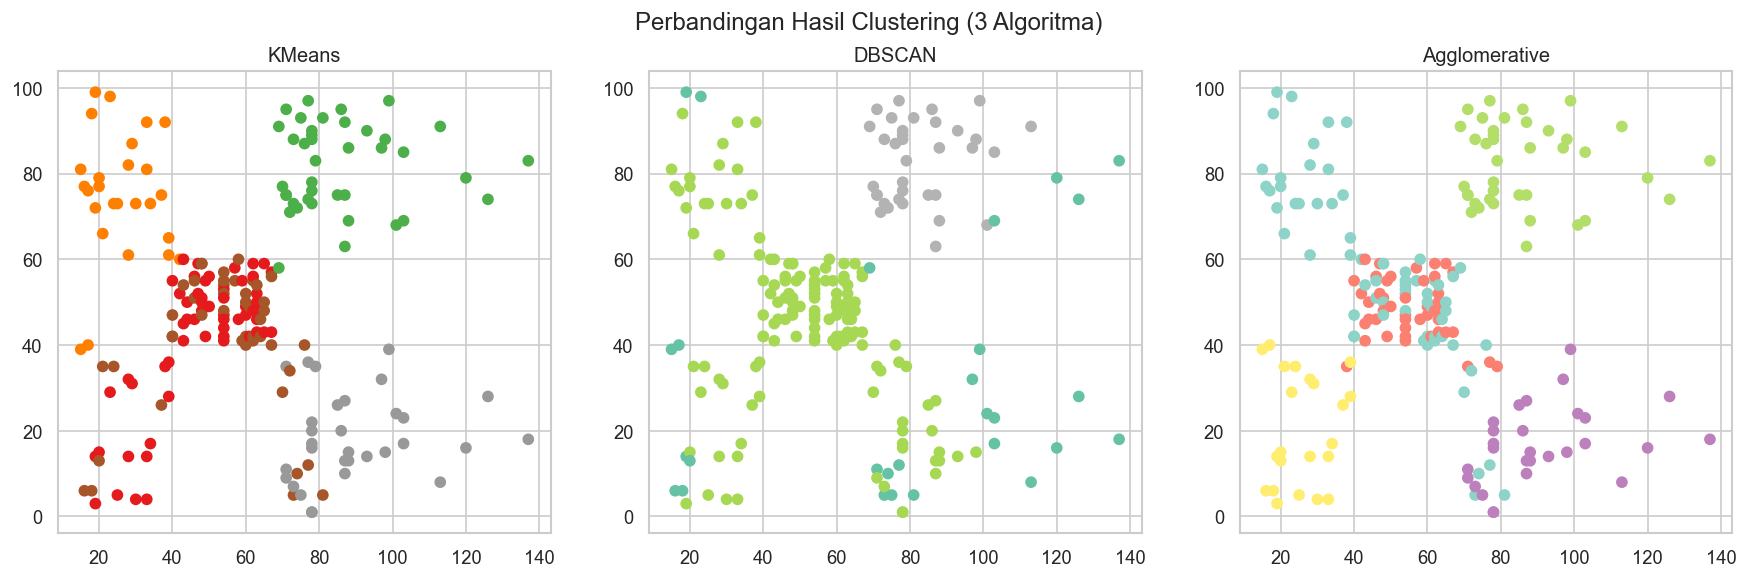

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_KMeans'], cmap='Set1')
axs[0].set_title('KMeans')

axs[1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_DBSCAN'], cmap='Set2')
axs[1].set_title('DBSCAN')

axs[2].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster_Agg'], cmap='Set3')
axs[2].set_title('Agglomerative')

plt.suptitle("Perbandingan Hasil Clustering (3 Algoritma)")
plt.show()


In [15]:
# Additional comparison table.
comparison_summary = pd.DataFrame(
    [
        {
            "Algorithm": "KMeans",
            "Number of Labels": df['Cluster_KMeans'].nunique(),
            "Noise Points": 0,
            "Silhouette Score": safe_silhouette(X_scaled, df['Cluster_KMeans']),
        },
        {
            "Algorithm": "DBSCAN",
            "Number of Labels": df['Cluster_DBSCAN'].nunique(),
            "Noise Points": int((df['Cluster_DBSCAN'] == -1).sum()),
            "Silhouette Score": safe_silhouette(X_scaled, df['Cluster_DBSCAN']),
        },
        {
            "Algorithm": "Agglomerative",
            "Number of Labels": df['Cluster_Agg'].nunique(),
            "Noise Points": 0,
            "Silhouette Score": safe_silhouette(X_scaled, df['Cluster_Agg']),
        },
    ]
)
display(comparison_summary.round(4))


,Algorithm,Number of Labels,Noise Points,Silhouette Score
0,KMeans,5,0,0.4085
1,DBSCAN,3,28,0.1880
2,Agglomerative,5,0,0.3900


### Additional 3D Visualization Including Age

The previous comparison plot only uses `Annual Income (k$)` and `Spending Score (1-100)`. That is useful, but the clustering models were trained using three features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. Because of that, a 3D visualization is helpful to check whether some visually confusing points in the 2D plot become more understandable when age is included.


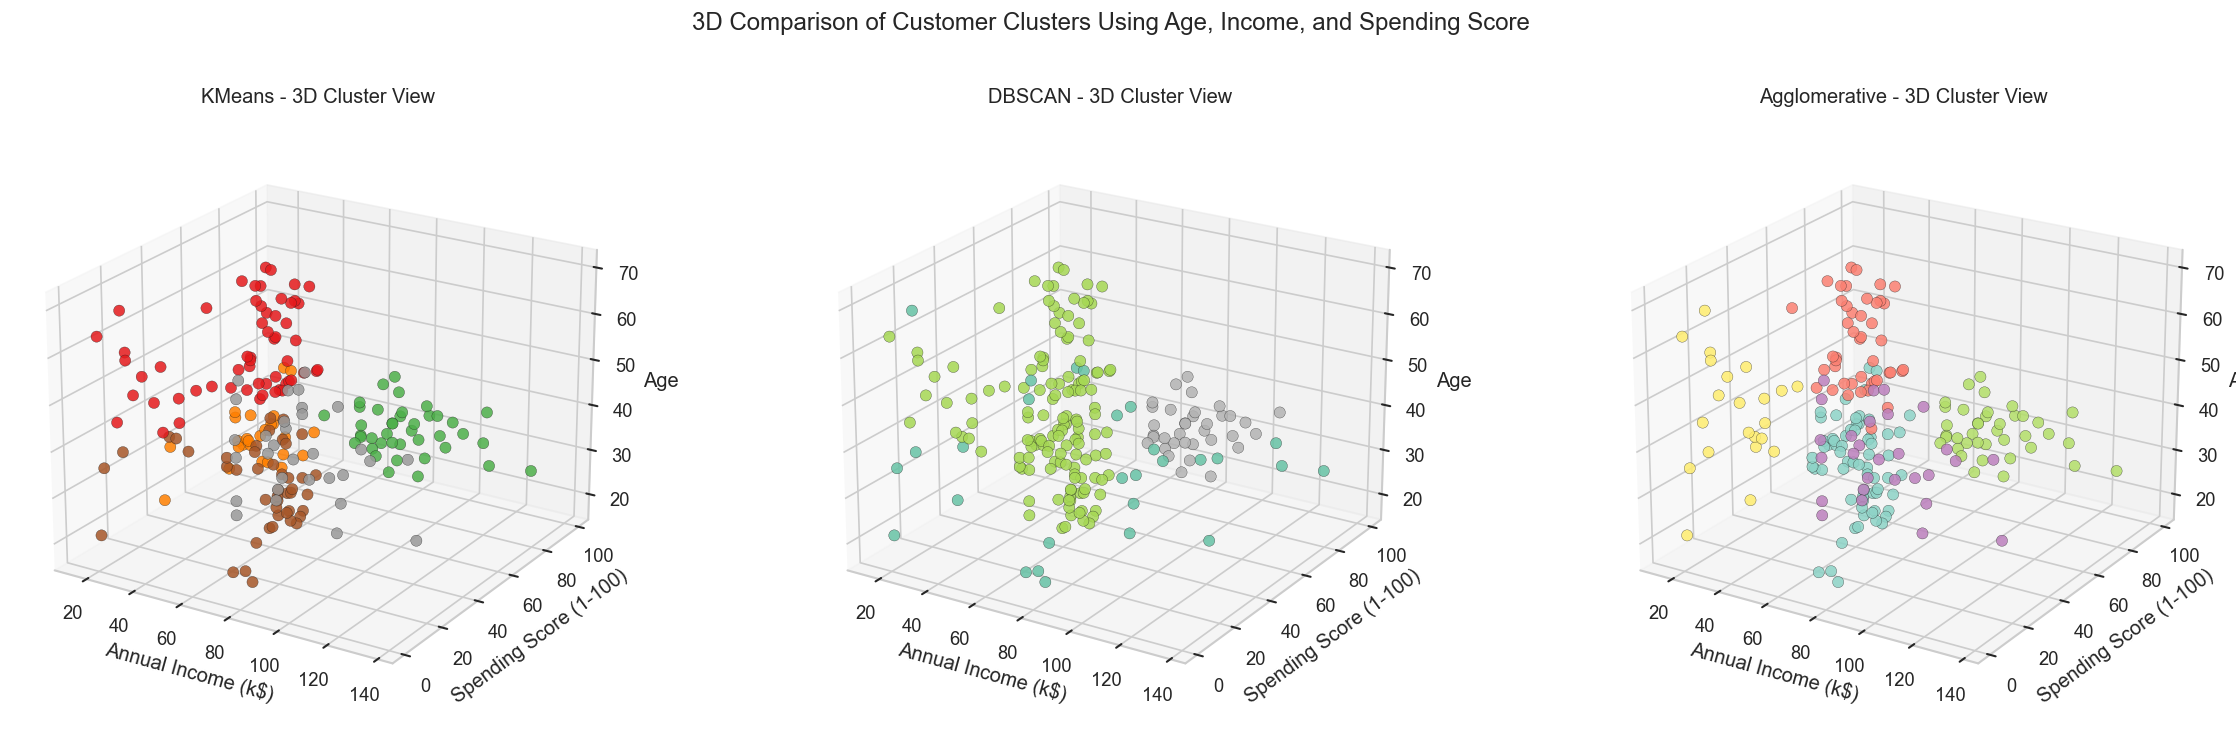

In [16]:
# Additional 3D comparison including Age.
cluster_views = [
    ('Cluster_KMeans', 'KMeans', 'Set1'),
    ('Cluster_DBSCAN', 'DBSCAN', 'Set2'),
    ('Cluster_Agg', 'Agglomerative', 'Set3'),
]

fig = plt.figure(figsize=(20, 6))

for index, (cluster_column, title, color_map) in enumerate(cluster_views, start=1):
    ax = fig.add_subplot(1, 3, index, projection='3d')
    scatter = ax.scatter(
        df['Annual Income (k$)'],
        df['Spending Score (1-100)'],
        df['Age'],
        c=df[cluster_column],
        cmap=color_map,
        s=45,
        alpha=0.85,
        edgecolor='k',
        linewidth=0.2,
    )
    ax.set_title(f'{title} - 3D Cluster View')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_zlabel('Age')
    ax.view_init(elev=22, azim=-58)

plt.suptitle('3D Comparison of Customer Clusters Using Age, Income, and Spending Score', y=1.02)
plt.tight_layout()
plt.show()


**3D Visualization Insight:** The 3D view makes the analysis more complete because it shows the hidden `Age` dimension. In the 2D plot, some customers may look close to another cluster based only on income and spending score. After adding age, those same customers may be farther away in the full feature space. This explains why visual judgment from a flat chart can disagree with the clustering result. The model is not only comparing two coordinates; it compares all selected features after scaling. This is also why feature selection is important in clustering: adding or removing one feature can change the cluster boundaries.


## TODO #7 **Analisis Visual: Perbandingan Hasil Clustering (3 Algoritma)**

### **1. KMeans**

KMeans gives the clearest business-style segmentation among the three starter models. The clusters are visible in the income-spending plot and can be interpreted as customer groups such as high-income high-spending, high-income low-spending, and lower-income high-spending customers. The result is not perfect because the algorithm assumes compact groups around centroids, but it is still practical and easy to explain.

One important visual observation is that some points look like they could belong to a nearby cluster when I only look at the two-dimensional plot. This does not always mean the model is wrong. The model was trained using three scaled features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. The comparison plot only shows income and spending score, so the age dimension is hidden. A point that looks close in 2D may be farther away in the full 3D feature space after scaling. This is a useful reminder that clustering visuals are simplifications, not the full mathematical view. The additional 3D plot helps confirm this by showing that age can affect why a customer belongs to a certain cluster.

---

### **2. DBSCAN**

DBSCAN behaves differently because it searches for dense regions instead of forcing every customer into a fixed number of clusters. In this result, DBSCAN creates fewer main groups and labels some customers as `-1`, meaning noise or outliers. This is useful for detecting unusual customers, but the segmentation is less balanced and less informative for general marketing groups compared with KMeans.

Visually, DBSCAN can look surprising because some separated points may share the same color, while some nearby-looking points may be labeled as noise. That happens because DBSCAN depends on density, `eps`, and `min_samples`, not on a fixed number of clusters. So, the question is not only "which point is nearest?" but also "is this point inside a dense neighborhood?"

---

### **3. Agglomerative Clustering**

Agglomerative Clustering produces a result that is visually close to KMeans because it is also set to create five clusters. The difference is in how it reaches the groups: it builds clusters by merging similar customers step by step. The output is useful and interpretable, although its silhouette score is slightly below KMeans in this workflow.

Some visual boundaries may still feel debatable because hierarchical clustering follows a merge history. Once groups are merged, the final cluster assignment depends on that hierarchy. This explains why it can sometimes group points differently from KMeans even when the final number of clusters is the same.

---

### **Additional Learning Reference**

To understand clustering behavior more intuitively, I also use an interactive clustering visualizer such as: https://clustering-visualizer.web.app/mean-shift

A visualizer is useful because it shows how different clustering assumptions can produce different boundaries. This supports the main lesson from this notebook: clustering is not only about running an algorithm. I need to understand the distance metric, the selected features, the parameter choices, and the business purpose behind the segmentation.

---

## Kesimpulan Naratif

Overall, KMeans is the most suitable starter model for this Mall Customers dataset because it gives clear, balanced, and business-friendly customer segments. Agglomerative Clustering is also reasonable and gives a similar interpretation, but KMeans is simpler to explain. DBSCAN is less suitable as the main segmentation model with the current parameters because it forms a very large cluster and several noise points, but it is useful as an additional method for identifying unusual customers.

The most important lesson is that clustering results should not be accepted blindly. The 3D visualization makes this clearer because the model uses `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`, while a normal 2D scatter plot hides one of those dimensions. Metrics such as silhouette score help, but they do not replace visual inspection and context. If a point visually looks closer to another cluster, I should ask what features are being plotted, what features were used in the model, whether scaling changed the distances, and what the business goal actually needs. That kind of reasoning makes the analysis more reliable than simply choosing the highest score.
